# Sistema de Puntos McDonald's — BATCH (Sistema Actual)

Todos los clientes ganan puntos a la misma tasa: **10 puntos por cada $1 gastado**. Los puntos se acreditan una vez al día en un proceso nocturno (batch).

---

## 1. Librerías y parámetros

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

np.random.seed(42)

N_CLIENTES    = 120
N_TRANSAC     = 600
INICIO        = datetime(2024, 4, 1)
FIN           = datetime(2024, 4, 30, 23, 59)
PUNTOS_X_PESO = 10
BATCH_HORAS   = 24

MC_ROJO     = '#DA291C'
MC_AMARILLO = '#FFC72C'
MC_GRIS     = '#27251F'
MC_CLARO    = '#F5F0E8'

## 2. Datos sintéticos

In [8]:
clientes = pd.DataFrame({
    'cliente_id': range(1, N_CLIENTES + 1),
    'nombre'    : [f'Cliente_{i:03d}' for i in range(1, N_CLIENTES + 1)],
})

seg_totales = int((FIN - INICIO).total_seconds())

transacciones = pd.DataFrame({
    'tx_id'     : range(1, N_TRANSAC + 1),
    'cliente_id': np.random.choice(clientes['cliente_id'], size=N_TRANSAC),
    'monto'     : np.round(np.random.exponential(scale=8, size=N_TRANSAC) + 2, 2),
    'timestamp' : [
        INICIO + timedelta(seconds=int(s))
        for s in np.random.randint(0, seg_totales, N_TRANSAC)
    ],
})

transacciones = transacciones.sort_values('timestamp').reset_index(drop=True)
transacciones['puntos'] = np.floor(transacciones['monto'] * PUNTOS_X_PESO).astype(int)

print(f'Clientes: {len(clientes)} | Transacciones: {len(transacciones)}')
print(transacciones.head())

Clientes: 120 | Transacciones: 600
   tx_id  cliente_id  monto           timestamp  puntos
0    262          39   6.93 2024-04-01 03:08:23      69
1    531          58   5.79 2024-04-01 05:32:55      57
2    434           4  50.57 2024-04-01 06:13:51     505
3    578          62  10.24 2024-04-01 07:15:55     102
4    520          32  17.77 2024-04-01 08:46:25     177


## 3. Limpieza de datos

In [9]:
n_antes = len(transacciones)

transacciones = transacciones[transacciones['monto'] > 0]
transacciones = transacciones[
    (transacciones['timestamp'] >= INICIO) &
    (transacciones['timestamp'] <= FIN)
]
transacciones = transacciones.drop_duplicates(subset='tx_id').reset_index(drop=True)

print(f'Registros antes: {n_antes} | Después: {len(transacciones)} | Eliminados: {n_antes - len(transacciones)}')

Registros antes: 600 | Después: 600 | Eliminados: 0


## 4. Sistema BATCH

Los puntos de cada compra quedan disponibles al final del ciclo de 24 horas en que ocurrió la transacción. Si compras a las 8 AM, tus puntos aparecen a medianoche.

In [10]:
transacciones['ciclo'] = transacciones['timestamp'].apply(
    lambda ts: int((ts - INICIO).total_seconds() / 3600 // BATCH_HORAS)
)

transacciones['disponible'] = transacciones['ciclo'].apply(
    lambda c: INICIO + timedelta(hours=(c + 1) * BATCH_HORAS)
)

transacciones['latencia_h'] = (
    transacciones['disponible'] - transacciones['timestamp']
).dt.total_seconds() / 3600

print(f"Latencia media : {transacciones['latencia_h'].mean():.1f} h")
print(f"Latencia máxima: {transacciones['latencia_h'].max():.1f} h")
print(f"Latencia mínima: {transacciones['latencia_h'].min():.2f} h")

Latencia media : 12.0 h
Latencia máxima: 24.0 h
Latencia mínima: 0.01 h


## 5. Visualización

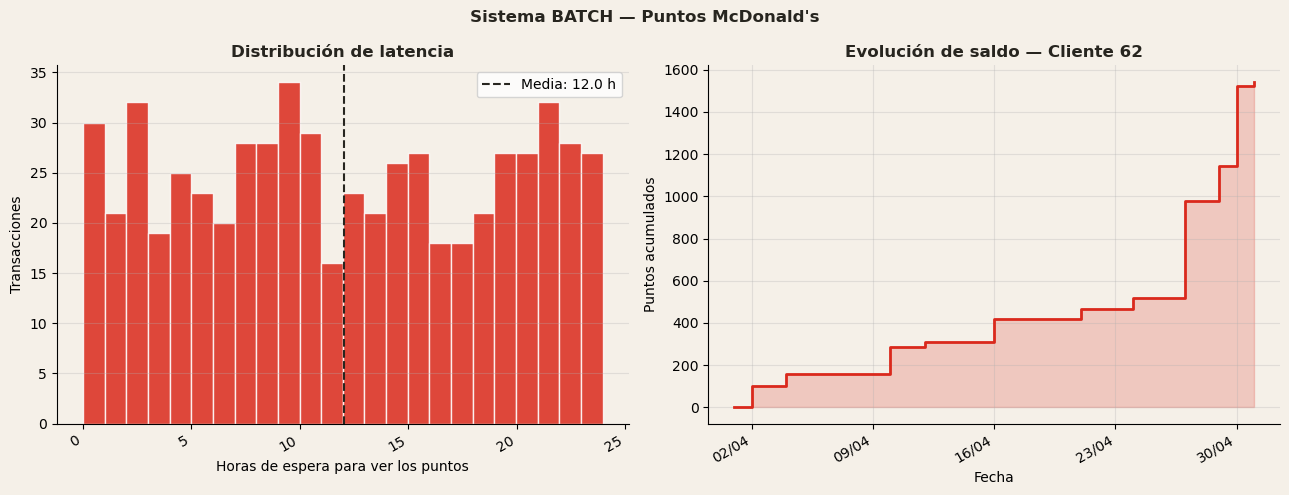

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(MC_CLARO)
fig.suptitle('Sistema BATCH — Puntos McDonald\'s', fontweight='bold', color=MC_GRIS)

# Gráfica 1: distribución de latencia
ax1 = axes[0]
ax1.set_facecolor(MC_CLARO)
ax1.hist(transacciones['latencia_h'], bins=24, color=MC_ROJO, edgecolor='white', alpha=0.85)
ax1.axvline(transacciones['latencia_h'].mean(), color=MC_GRIS, linestyle='--',
            label=f"Media: {transacciones['latencia_h'].mean():.1f} h")
ax1.set_title('Distribución de latencia', color=MC_GRIS, fontweight='bold')
ax1.set_xlabel('Horas de espera para ver los puntos')
ax1.set_ylabel('Transacciones')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# Gráfica 2: evolución del saldo (escalones diarios por el ciclo batch)
ax2 = axes[1]
ax2.set_facecolor(MC_CLARO)
cliente_ej = transacciones.groupby('cliente_id')['tx_id'].count().idxmax()
tx_ej = transacciones[transacciones['cliente_id'] == cliente_ej].sort_values('timestamp').copy()

saldo_batch = (
    tx_ej.groupby('disponible')['puntos'].sum()
    .reset_index().sort_values('disponible')
)
saldo_batch['saldo'] = saldo_batch['puntos'].cumsum()

tiempos = [INICIO] + list(saldo_batch['disponible']) + [FIN]
saldos  = [0] + list(saldo_batch['saldo']) + [saldo_batch['saldo'].iloc[-1]]
ax2.step(tiempos, saldos, where='post', color=MC_ROJO, linewidth=2)
ax2.fill_between(tiempos, saldos, step='post', alpha=0.2, color=MC_ROJO)
ax2.set_title(f'Evolución de saldo — Cliente {cliente_ej}', color=MC_GRIS, fontweight='bold')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Puntos acumulados')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator())
ax2.grid(alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig('batch_resultados.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Resumen

In [12]:
print('=== SISTEMA BATCH ===')
print(f"Transacciones   : {len(transacciones)}")
print(f"Clientes activos: {transacciones['cliente_id'].nunique()}")
print(f"Puntos emitidos : {transacciones['puntos'].sum():,}")
print(f"Latencia media  : {transacciones['latencia_h'].mean():.1f} h")
print(f"Latencia máxima : {transacciones['latencia_h'].max():.1f} h")

=== SISTEMA BATCH ===
Transacciones   : 600
Clientes activos: 119
Puntos emitidos : 60,176
Latencia media  : 12.0 h
Latencia máxima : 24.0 h
